# Urban Flood Watch: Precipitation Mapping in Galați, Romania

This notebook utilizes Google Earth Engine (GEE) and the CHIRPS daily climate dataset to calculate and visualize cumulative rainfall over a specific time period. It dynamically fetches city boundaries using the Nominatim API and overlays the total precipitation data onto an interactive map.

## Environment Setup & Authentication

In [122]:
# library imports
from datetime import datetime
import ee
import sys
import json
import time
import requests
import geemap

In [ ]:
## Initialize the Earth Engine module.

service_account = 'To DO'
credentials = ee.ServiceAccountCredentials(service_account, 'To DO')
ee.Initialize(credentials)

## Date filter from user input

In [124]:
# date_start_str = input("Enter the start date (YYYY-MM-DD): ")
# date_stop_str = input("Enter the end date (YYYY-MM-DD): ")

date_start_str = '2018-05-01'
date_stop_str = '2018-05-31'
try:
    start_date = datetime.strptime(date_start_str, "%Y-%m-%d")
    stop_date = datetime.strptime(date_stop_str, "%Y-%m-%d")
    
    if start_date >= stop_date:
        print("Error: The start date must be before the end date.")
        sys.exit(1)
        
except ValueError:
    print("Error: Incorrect date format. Please strictly use YYYY-MM-DD.")
    sys.exit(1)

print(f"Successfully set date range: {date_start_str} to {date_stop_str}")

Successfully set date range: 2018-05-01 to 2018-05-31


In [125]:
DATE_FILTER = ee.Filter.date(date_start_str, date_stop_str)

## Retrieving the Area of Interest (AOI)

In [126]:
def get_bbox(city_name  = 'Galati', address_type = 'city'):
    url = f"https://nominatim.openstreetmap.org/search.php?q={city_name}&polygon_geojson=1&format=json"
    
    # Nominatim STRICTLY requires a User-Agent header. 
    # Replace the email with your own to avoid getting blocked.
    headers = {
        'User-Agent': 'FloodWatchApp/1.0 '
    }
    
    for attempt in range(10):
        try:
            response = requests.get(url, headers=headers, timeout=15)
            response.raise_for_status()
            data = response.json()
            
            if not data:
                print(f"No data found for {city_name}")
                return None

            bounding_box = None
            city_data_match = None

            for city_data in data:
                if city_data.get('type') == 'administrative' and city_data.get('addresstype') == address_type:
                    bounding_box = city_data.get('geojson').get('coordinates')
                    city_data_match = city_data
                    break

            geometry_type = city_data_match.get('geojson').get('type')
            
            if geometry_type == 'MultiPolygon':
                return bounding_box[0][0]
            elif geometry_type == 'Polygon':
                return bounding_box[0]

        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            time.sleep(2)
            
    return None

In [127]:
bounding_box = get_bbox()
print(bounding_box)

if bounding_box:
    aoi = ee.Geometry.Polygon([bounding_box])
else:
    aoi = None

if aoi is None:
    print("Failed to retrieve AOI for the given city and address type.")
    sys.exit(1)

[[27.9433558, 45.4525557], [27.9433814, 45.4500851], [27.9436818, 45.4488129], [27.9444953, 45.4476721], [27.9447878, 45.4476482], [27.9450369, 45.4462281], [27.9452085, 45.4459935], [27.9455094, 45.445935], [27.9459638, 45.4458786], [27.9461329, 45.4458987], [27.9469443, 45.4459812], [27.9472709, 45.4458926], [27.9477843, 45.4460494], [27.9480789, 45.4461786], [27.9503614, 45.4464867], [27.952052, 45.446703], [27.9525751, 45.4467506], [27.9529025, 45.4467754], [27.9543628, 45.4468653], [27.9549207, 45.4468949], [27.9566984, 45.446845], [27.9569396, 45.4468343], [27.9568877, 45.4455788], [27.9569035, 45.4454172], [27.956928, 45.4452996], [27.9570067, 45.4451166], [27.9592891, 45.4409473], [27.9594552, 45.4409439], [27.9595646, 45.440617], [27.9632673, 45.4361045], [27.9630087, 45.4360015], [27.9649133, 45.4339234], [27.96357, 45.4339594], [27.9609902, 45.4340212], [27.9607443, 45.4338422], [27.9602335, 45.4338555], [27.960223, 45.4335587], [27.9603545, 45.4335561], [27.9603284, 45.4328

## Creating the map

We are using the **CHIRPS Daily: Climate Hazards Group InfraRed Precipitation with Station data** (Resolution: ~5.5km). 

Because CHIRPS is a daily dataset, we apply the `.sum()` reducer to calculate the **cumulative total rainfall** across our entire selected date range, and `.clip()` it strictly to the Galați city limits.

In [128]:
Map = geemap.Map()
Map.centerObject(aoi, zoom=10)

In [129]:
Map.setOptions('SATELLITE')

In [130]:
chirps_collection = ee.ImageCollection("UCSB-CHC/CHIRPS/V3/DAILY_SAT")

In [131]:
filtered_precip = (chirps_collection
                   .filterBounds(aoi)
                   .filter(DATE_FILTER)
                   .select('precipitation'))

In [ ]:
total_precip = filtered_precip.sum().clip(aoi)
# total_precip = filtered_precip.median().clip(aoi)

In [133]:
precip_vis = {
    'min': 1.0,
    'max': 17.0,
    'palette': ['#001137', '#0aab1e', '#e7eb05', '#2c7fb8', '#253494']
}

In [134]:

Map.addLayer(total_precip, precip_vis, f"Total Precipitation ({date_start_str} to {date_stop_str})")
Map.addLayer(ee.Image().paint(aoi, 0, 2), {'palette': 'red'}, "City Boundary")


## Display the output map

In [135]:
Map

Map(center=[45.48810661908869, 28.078510682104586], controls=(WidgetControl(options=['position', 'transparent_…

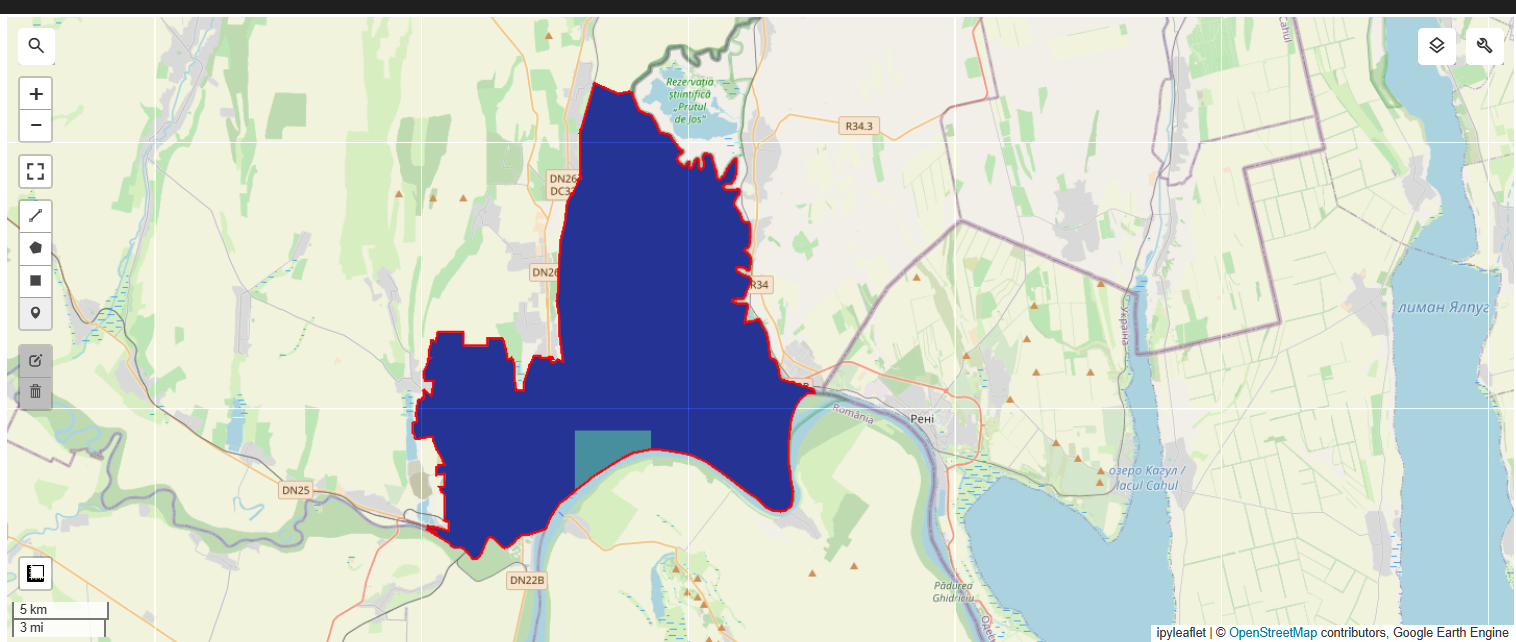

# Conclusions

Data that I have used: https://developers.google.com/earth-engine/datasets/catalog/UCSB-CHC_CHIRPS_V3_DAILY_SAT

Pixel Size 5566 meters

The Math Behind the Blocks:
- A pixel size of 5566 meters means that a single "square" of data on your map is roughly 5.5 km by 5.5 km.
- The area of one single CHIRPS pixel is about 31 km².The total surface area of Galați is 246.4 km².
- If you divide Galați's area by the size of one pixel ($246.4 \div 31$), it means the entire city of Galați is covered by only about **8 pixels** .

Final Thoughts:

You can't get better rainfall resolution than CHIRPS (~5km is actually considered "high resolution" for global precipitation).

 Instead, use CHIRPS to get the total volume of water falling on the city, and then use a Digital Elevation Model (DEM) to see where that water will pool.
